In [1]:
import xarray as xr
import hvplot.xarray
import s3fs

s3 =  s3fs.S3FileSystem(anon=True)

In [2]:
ds = xr.open_zarr("s3://maap-ops-workspace/shared/alexdevseed/imerg_precip_clim/daily.zarr", consolidated=False)
ds

<xarray.Dataset> Size: 9GB
Dimensions:        (doy: 365, lat: 1800, lon: 3600)
Coordinates:
  * doy            (doy) int64 3kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * lat            (lat) float32 7kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon            (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
Data variables:
    precipitation  (doy, lat, lon) float32 9GB dask.array<chunksize=(20, 900, 1800), meta=np.ndarray>
Attributes:
    title:        IMERG Final Daily Climatological Precipitation (2001 to 2022)
    description:  Average of all valid daily precipitation on January 01 from...
    version:      V07B
    source:       IMERG Final Daily Precipitation (10.5067/GPM/IMERGDF/DAY/07)
    comment:      A value is given only in a grid box if at least 90% of the ...
    Conventions:  CF-1.8

In [3]:
bbox = [-132.493985,18.64444,-63.035768,52.292592]
ds_clipped = ds.sel(
    lon=slice(bbox[0], bbox[2]), 
    lat=slice(bbox[1], bbox[3])
)
ds_clipped['precipitation'].hvplot(
    x='lon', y='lat', cmap="Reds", rasterize=True, coastline=True,
)

:DynamicMap   [doy]
   :Overlay
      .Image.I     :Image   [lon,lat]   (climatological precipitation)
      .Coastline.I :Feature   [Longitude,Latitude]

TypeError: Axes.hist() got multiple values for argument 'x'

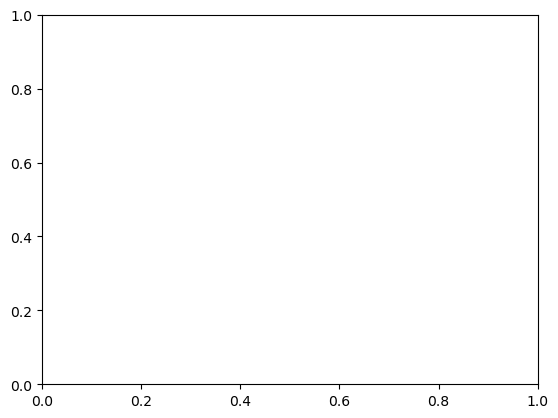

In [4]:
ds_clipped['precipitation'].plot(
    x='lon', y='lat', cmap="Reds", rasterize=True, coastline=True,
)